In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("../data/student-mat.csv", sep = ";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [7]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

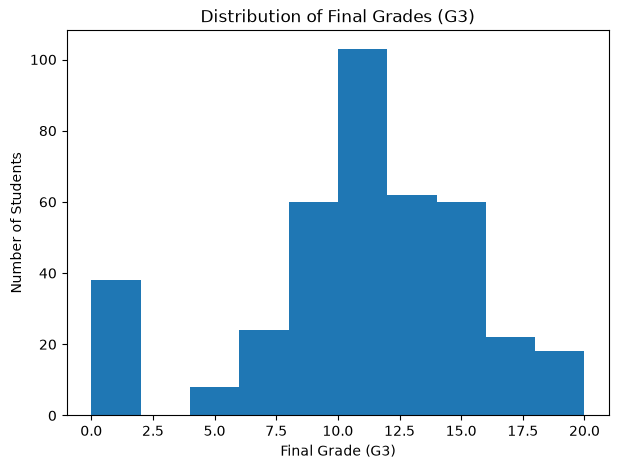

In [8]:
plt.figure(figsize = (7, 5))
plt.hist(df["G3"], bins = 10)
plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")
plt.show()

In [9]:
df.select_dtypes(include = "str").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='str')

In [10]:
df_encoded = df.copy()

In [12]:
df_encoded.dtypes

school        int64
sex           int64
age           int64
address       int64
famsize       int64
Pstatus       int64
Medu          int64
Fedu          int64
Mjob          int64
Fjob          int64
reason        int64
guardian      int64
traveltime    int64
studytime     int64
failures      int64
schoolsup     int64
famsup        int64
paid          int64
activities    int64
nursery       int64
higher        int64
internet      int64
romantic      int64
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64
dtype: object

In [39]:
selected_features = [
    "studytime",
    "failures",
    "absences",
    "internet",
    "higher",
    "G1",
    "G2"
]

X = df_encoded[selected_features]

In [40]:
y = df_encoded["G3"]
y.shape

(395,)

In [41]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42
)

In [42]:
y_train.shape

(316,)

In [44]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_predictions = lr.predict(X_test)
lr_predictions[:10]

array([ 5.76248559, 11.87243937,  3.44380988,  8.51049609,  8.09299854,
       12.68032084, 18.66236537,  7.0927977 ,  7.20301317, 12.80135402])

In [22]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": lr_predictions
})
comparison.head(10)

,Actual,Predicted
0,10,6.281525
1,12,11.326917
2,5,3.032521
3,10,8.037261
4,9,8.555778
5,13,12.367039
6,18,18.684816
7,6,7.540692
8,0,6.988232
9,14,12.360205


In [46]:
mae = mean_absolute_error(y_test, lr_predictions)
print("MAE", mae)

MAE 1.3304941405810642


In [47]:
mse = mean_squared_error(y_test, lr_predictions)
print("MSE", mse)

MSE 4.449983971798649


In [48]:
import numpy as np

In [49]:
rmse = np.sqrt(mse)
print("RMSE", rmse)

RMSE 2.1094985119214114


In [50]:
r2 = r2_score(y_test, lr_predictions)
print("R2 Score", r2)

R2 Score 0.7829810429781877


In [ ]:
dt = DecisionTreeRegressor(random_state = 42)
dt.fit(X_train, y_train)
dt_predictions = dt.predict(X_test)
print("MAE:", mean_absolute_error(y_test, dt_predictions))
print("MSE:", mean_squared_error(y_test, dt_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, dt_predictions)))
print("R2:", r2_score(y_test, dt_predictions))

MAE: 1.0253164556962024
MSE: 3.0759493670886076
RMSE: 1.7538384666464035
R2: 0.84999062294877


In [52]:
rf = RandomForestRegressor(random_state = 42)
rf.fit(X_train, y_train)
rf_predictions = rf.predict(X_test)
print("MAE:", mean_absolute_error(y_test, rf_predictions))
print("MSE:", mean_squared_error(y_test, rf_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_predictions)))
print("R2:", r2_score(y_test, rf_predictions))

MAE: 1.0687600964436408
MSE: 2.853013767057034
RMSE: 1.6890866665322517
R2: 0.8608628534351034


In [30]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, dt_predictions),
        mean_absolute_error(y_test, rf_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, dt_predictions)),
        np.sqrt(mean_squared_error(y_test, rf_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, dt_predictions),
        r2_score(y_test, rf_predictions)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.495475,2.243300,0.754578
1,Decision Tree,1.278481,2.368036,0.726526
2,Random Forest,1.121013,1.873620,0.828801


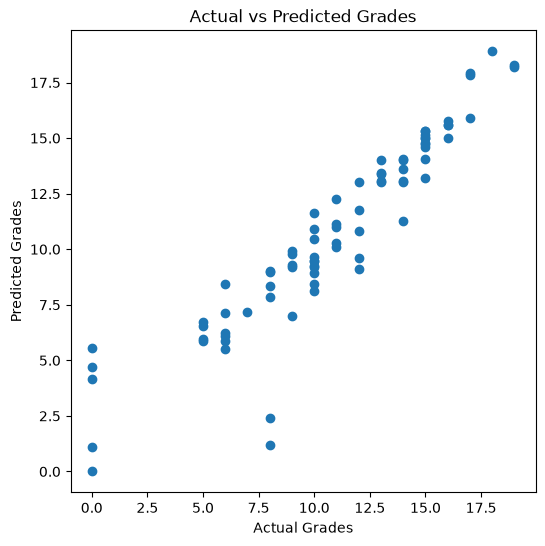

In [53]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Grades")

plt.ylabel("Predicted Grades")

plt.title("Actual vs Predicted Grades")

plt.show()

In [54]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
6,G2,0.809837
2,absences,0.118410
5,G1,0.030336
0,studytime,0.019724
1,failures,0.014161
3,internet,0.006196
4,higher,0.001336


In [ ]:
rf_tuned = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)
rf_tuned.fit(X_train, y_train)
rf_tuned_predictions = rf_tuned.predict(X_test)
print("MAE:", mean_absolute_error(y_test, rf_tuned_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_tuned_predictions)))
print("R2:", r2_score(y_test, rf_tuned_predictions))

MAE: 1.0873866787221218
RMSE: 1.710998763573914
R2: 0.8572294552321909


In [57]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    rf_tuned,
    X,
    y,
    cv=5,
    scoring="r2"
)
print(scores.mean())

0.8108238297997733


In [58]:
import pickle
with open("../models/student_model.pkl", "wb") as file:
    pickle.dump(rf_tuned, file)

In [59]:
with open("../models/student_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

In [ ]:
loaded_predictions = loaded_model.predict(X_test)
loaded_predictions[:5]

array([ 8.375, 11.765,  6.78 ,  9.39 ,  9.155])